````{margin}
```{attributiongrey} Bronvermelding
:class: attribution

Deze oefening is gebaseerd op [deze oefening uit het online boek van het vak CT1000S Structural Mechanics op de Technische Universiteit Delft](https://oit.tudelft.nl/CT1000/2025/week_3/session_3/intro.html) {cite:p}`CT1000_2025`.

```
````

# Begeleide oefening 1

Gegeven is de volgende constructie:

```{figure-start} ./lesoefening1_data/constructie.svg
:align: center
:source: https://github.com/Structural-Mechanics-CEG/mechanics-figures-source/tree/main/sympy2
:number:
```

$$EI = 30 \, \rm{MNm}^2$$

```{figure-end}
```

Vind de maximale doorzakking en de maximale momenten in beide richtingen (◠ and ◡). Je kan gebruik maken van de code hieronder, klik daarvoor op {fa}`rocket` --> {guilabel}`Live Code`. Als je je resultaten wilt opslaan, maak de opdracht dan in [WebLab](https://weblab.tudelft.nl/ctb1310/2025-2026/assignment/163459/info). Heb je nog geen toegang? Schrijf je dan eerst [hier](https://weblab.tudelft.nl/ctb1310/2025-2026/enroll) in voor dit vak op WebLab.

In [1]:
import sympy as sym
sym.init_printing(use_latex='mathjax')
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display as ipy_display, Math

%config InlineBackend.figure_formats = ['svg']

def display(*objs):
    for obj in objs:
        if isinstance(obj, dict):
            lines = [f"{sym.latex(k)} &= {sym.latex(obj[k])}" for k in sorted(obj, key=lambda s: str(s))]
            ipy_display(Math(r"\begin{aligned}" + r"\\ ".join(lines) + r"\end{aligned}"))
        else:
            ipy_display(obj)

def plot(w_list, x_range_list,ylabel):
    fig = plt.figure(facecolor='none')
    for i, w in enumerate(w_list):
        # check if x is the only symbol in the expression
        if len(w.free_symbols) > 1:
            raise ValueError('The expression must be a function of x only.')
        
        w_numpy = sym.lambdify(x, w)
        x_vals = np.linspace(x_range_list[i][0], x_range_list[i][1], 100)
        
        # if the expression is a constant, we need to make sure that it is broadcasted correctly
        if isinstance(w_numpy(x_vals),float) or isinstance(w_numpy(x_vals),int):
            w_numpy = np.vectorize(w_numpy)
        plt.plot(x_vals,w_numpy(x_vals))
        plt.xlabel('$x$')
        plt.ylabel(ylabel)
    ax = plt.gca()
    ax.set_facecolor('none')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.invert_yaxis()

In [ ]:
import sympy as sym

In [ ]:
sym.var('x')
sym.var('C1 C2 C3 C4 ...');

In [ ]:
q1 = ...
...

In [ ]:
V1 = sym.integrate(-q1,x)+C1
M1 = sym.integrate(V1,x)+C2
kappa1 = M1 / ...
phi1 = sym.integrate(kappa1,x)+C3
w1 = sym.integrate(-phi1,x)+C4

...

In [ ]:
Eq1 = sym.Eq(...,...)
Eq2 = ...

In [ ]:
sol = sym.solve((Eq1, Eq2, Eq3, Eq4, ...), (C1, C2, C3, C4, ...))
display(sol)

In [ ]:
..._oplossing = ....subs(sol)
...

display(..._oplossing)
...

In [ ]:
plot([...,...],[...,...],'...')
...

::::{question} Opgave
:type: short-answer
:variant: blocks
:showanswer:
:admonition:
:class: exercise
:nocaption:
Wat is de maximale doorzakking in $\rm{mm}$?
---
MRP[37387/300000;0.025]
---

::::

::::{question} Opgave
:type: short-answer
:variant: blocks
:showanswer:
:admonition:
:class: exercise
:nocaption:

---
MRP[595/2;0.025] Wat is het maximale negatieve moment in $\rm{kNm}$ (◠)? Geef de absolute waarde.

MRP[36;0.025] Wat is het maximale positieve moment in $\rm{kNm}$ (◡)? Geef de absolute waarde.
---

::::

::::{admonition-start} Uitwerking
:class: solution, dropdown
::::

In [2]:
import sympy as sym

In [3]:
sym.var('x')
sym.var('C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12');

In [4]:
q1 = x / 7 * (-21) + 21
q2 =  0
q3 =  0

In [5]:
V1 = sym.integrate(-q1,x)+C1
M1 = sym.integrate(V1,x)+C2
kappa1 = M1 / 30000
phi1 = sym.integrate(kappa1,x)+C3
w1 = sym.integrate(-phi1,x)+C4

V2 = sym.integrate(-q2,x)+C5
M2 = sym.integrate(V2,x)+C6
kappa2 = M2 / 30000
phi2 = sym.integrate(kappa2,x)+C7
w2 = sym.integrate(-phi2,x)+C8

V3 = sym.integrate(-q3,x)+C9
M3 = sym.integrate(V3,x)+C10
kappa3 = M3 / 30000
phi3 = sym.integrate(kappa3,x)+C11
w3 = sym.integrate(-phi3,x)+C12

In [6]:
Eq1  = sym.Eq(  w1.subs(x, 0), 0)
Eq2  = sym.Eq(phi1.subs(x, 0), 0)
Eq3  = sym.Eq(  w1.subs(x, 7),   w2.subs(x,7))
Eq4  = sym.Eq(  M1.subs(x, 7), 0)
Eq5  = sym.Eq(  M2.subs(x, 7), 0)
Eq6  = sym.Eq(  V1.subs(x, 7),   V2.subs(x, 7))
Eq7  = sym.Eq(  w2.subs(x, 9),   w3.subs(x, 9))
Eq8  = sym.Eq(phi2.subs(x, 9), phi3.subs(x, 9))
Eq9  = sym.Eq(  M2.subs(x, 9),   M3.subs(x, 9))
Eq10 = sym.Eq( -V2.subs(x, 9) + 30 + V3.subs(x, 9), 0)
Eq11 = sym.Eq(  w3.subs(x,12), 0)
Eq12 = sym.Eq(  M3.subs(x,12), 0)

In [7]:
sol = sym.solve((Eq1, Eq2, Eq3, Eq4, Eq5, Eq6, Eq7, Eq8, Eq9, Eq10, Eq11, Eq12), (C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12))
display(sol)

<IPython.core.display.Math object>

In [8]:
w1_oplossing = w1.subs(sol)
w2_oplossing = w2.subs(sol)
w3_oplossing = w3.subs(sol)
M1_oplossing = M1.subs(sol)
M2_oplossing = M2.subs(sol)
M3_oplossing = M3.subs(sol)

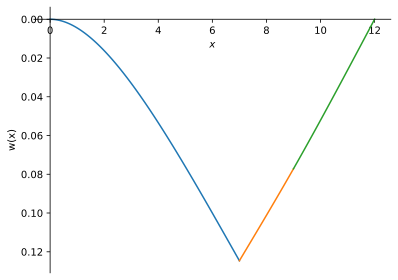

In [9]:
plot([w1_oplossing, w2_oplossing, w3_oplossing], [(0, 7), (7, 9), (9, 12)], 'w(x)')

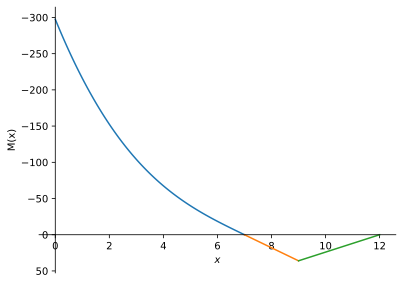

In [10]:
plot([M1_oplossing, M2_oplossing, M3_oplossing], [(0, 7), (7, 9), (9, 12)], 'M(x)')

In [11]:
w_max = w1_oplossing.subs(x, 7) # m
M_max_neg = M1_oplossing.subs(x, 0) # kNm
M_max_pos = M2_oplossing.subs(x, 9) # kNm

display(w_max)
display(M_max_neg)
display(M_max_pos)

37387 
──────
300000

-595/2

36

::::{admonition-end}
::::